In [3]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Cargar dataset real desde OpenML
data = fetch_openml(name='default-of-credit-card-clients', version=1, as_frame=True)
# Convertir a DataFrame
df = data.frame
# Visualizar los primeros registros
print(df.shape)
df.head()

(30000, 24)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x15,x16,x17,x18,x19,x20,x21,x22,x23,y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


NameError: name 'df' is not defined

## Descripción general
Este conjunto de datos contiene información financiera y demográfica de 30,000 clientes de tarjetas de crédito, con el fin de predecir si el cliente incumplirá el pago del mes siguiente (default.payment.next.month). Es ideal para segmentación de riesgo, clasificación crediticia y análisis de comportamiento financiero en contextos como SAGRILAFT


# Detección de LA/FT en Tarjetas de Crédito (Enfoque SAGRILAFT)

## 1️⃣ Perfilación inicial del cliente (KYC reforzado)
Antes de analizar movimientos, se define **cómo debería comportarse el cliente** según su información:
- Ingresos declarados.
- Actividad económica.
- Ubicación habitual.
- Historial de transacciones previas.
- Segmento de riesgo (alto, medio, bajo) según normativa.

**Objetivo:** Tener una “línea base” para detectar desviaciones.  
Ejemplo:  
> Un cliente con ingresos declarados de $4 millones mensuales no debería pagar $15 millones a su tarjeta en un solo mes sin justificación.

---

## 2️⃣ Variables clave a monitorear
En tarjetas de crédito, las más útiles para detectar LA/FT son:

| Variable | Señal de alerta |
|----------|-----------------|
| **Avances en efectivo** | Aumentos abruptos, operaciones repetidas el mismo día, uso en diferentes ciudades/países. |
| **Pagos a la tarjeta** | Monto alto, origen desconocido (terceros), pagos desde cuentas extranjeras o no registradas. |
| **Incrementos súbitos del gasto** | Pasar de un consumo promedio de $2M a $12M en un mes sin cambio de perfil. |
| **Compras internacionales** | En países catalogados como de alto riesgo por GAFI o sin relación con el cliente. |
| **Devoluciones frecuentes** | Compra de bienes de alto valor y devolución para recibir dinero en cuenta. |
| **Uso de múltiples tarjetas** | Pagos cruzados entre tarjetas del mismo cliente o de terceros. |

---

## 3️⃣ Técnicas de detección

### 🔹 a) Reglas de negocio (indicadores inusuales)
- Pagos superiores al 80% del límite de crédito en una sola transacción.  
- Más de X avances de efectivo en un día.  
- Pagos de más de $10 millones desde una cuenta no asociada.  
- Compras recurrentes en giros postales, joyerías, casas de empeño.  

### 🔹 b) Analítica avanzada / Machine Learning
- **Análisis de outliers**: detectar transacciones alejadas del comportamiento histórico del cliente.  
- **Modelos de clustering**: segmentar clientes por patrones de gasto y detectar cambios bruscos de segmento.  
- **Modelos supervisados**: entrenar un clasificador con operaciones históricas marcadas como sospechosas o confirmadas como LA/FT.  

---

## 4️⃣ Indicadores cruzados con default
En el dataset, la variable `default.payment.next.month` puede ser útil:
- Un cliente que **incumple pagos** y **hace operaciones atípicas** es doblemente riesgoso.
- Ejemplo: Deja de pagar, pero antes hace un avance de $8 millones y se desaparece.
- Esto podría ser indicio de **uso fraudulento o “quema” de crédito** para mover fondos ilícitos.

---

## 5️⃣ Ejemplo práctico de detección

| Mes | Gasto promedio | Pago total | Origen de pagos | Avances de efectivo |
|-----|----------------|------------|------------------|---------------------|
| Ene | $1.5M          | $1.5M      | Nómina           | $0                  |
| Feb | $1.7M          | $1.7M      | Nómina           | $0                  |
| Mar | $12M           | $12M       | Transferencia int. (Panamá) | $9M |
| Abr | $0             | $0         | —                | —                   |

**Alertas detectadas:**
- **Desviación brusca** en gasto y pagos.  
- Origen del pago desde jurisdicción de riesgo (Panamá).  
- Uso masivo de avance en efectivo.  
- Inactividad posterior (patrón típico de "layering").  

---

## 6️⃣ Flujo SAGRILAFT para tarjetas de crédito
1. **Definir perfil esperado** del cliente (KYC).  
2. **Monitorear diariamente** las variables clave.  
3. **Aplicar reglas y modelos analíticos** para generar alertas.  
4. **Analizar y documentar** la operación inusual.  
5. Si aplica, **reportar ROS** a la UIAF.  
6. **Retroalimentar** el sistema con casos confirmados.


| Variable                        | Descripción                                                                                                                           |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| **ID**                          | Identificador del cliente                                                                                                             |
| **LIMIT\_BAL**                  | Monto del crédito otorgado (en NT\$)                                                                                                  |
| **SEX**                         | Género (1 = Masculino, 2 = Femenino)                                                                                                  |
| **EDUCATION**                   | Nivel educativo (1 = posgrado, 2 = universidad, 3 = secundaria, 4 = otros)                                                            |
| **MARRIAGE**                    | Estado civil (1 = casado, 2 = soltero, 3 = otros)                                                                                     |
| **AGE**                         | Edad del cliente en años                                                                                                              |
| **PAY\_0** a **PAY\_6**         | Historial de pagos (estado de reembolso desde septiembre hasta abril, donde -1 = pago debidamente, 0 = al día, 1-9 = demora en meses) |
| **BILL\_AMT1** a **BILL\_AMT6** | Monto de la factura por mes (últimos 6 meses)                                                                                         |
| **PAY\_AMT1** a **PAY\_AMT6**   | Monto del pago realizado por mes (últimos 6 meses)                                                                                    |
| **default.payment.next.month**  | Variable objetivo: 1 = incumplimiento de pago, 0 = pago realizado                                                                     |


#Segmentacion

Se Propone una segmentación no supervisada primero (clustering), y luego analizar qué segmentos están asociados a mayor riesgo a partir de variables de alerta. Esto es muy coherente con un enfoque SAGRILAFT basado en perfiles.

| Variable      | Descripción breve                 |
| ------------- | --------------------------------- |
| `LIMIT_BAL`   | Crédito otorgado                  |
| `AGE`         | Edad del cliente                  |
| `BILL_AMT1-6` | Monto de facturación mensual      |
| `PAY_AMT1-6`  | Monto de pagos realizados por mes |


In [ ]:
# Paso 1: Librerías
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 2: Cargar dataset
data = fetch_openml(name='default-of-credit-card-clients', version=1, as_frame=True)
df = data.frame



# Paso 3: Renombrar columnas manualmente
df.columns = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "default.payment.next.month"
]

# Paso 4: Variables para clustering
variables_segmentacion = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

X = df[variables_segmentacion]


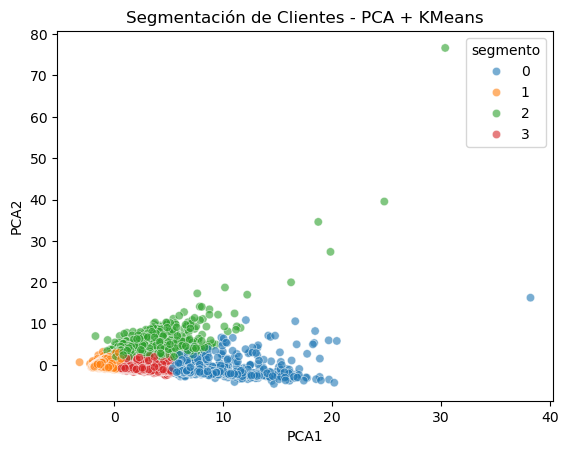

In [ ]:
#Paso 5: Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Paso 6: PCA para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Paso 7: KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df["segmento"] = kmeans.fit_predict(X_scaled)

# Paso 8: Visualizar clusters
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="segmento", palette="tab10", alpha=0.6)
plt.title("Segmentación de Clientes - PCA + KMeans")
plt.show()

In [ ]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,pagos_en_cero,facturacion_promedio,pago_promedio,deuda_acumulada,uso_credito,segmento
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,1,0,1284.000000,114.833333,1169.166667,0.064200,1
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,0,2000,1,0,2846.166667,833.333333,2012.833333,0.023718,1
2,90000,2,2,2,34,0,0,0,0,0,...,1000,1000,5000,0,0,16942.166667,1836.333333,15105.833333,0.188246,1
3,50000,2,2,1,37,0,0,0,0,0,...,1100,1069,1000,0,0,38555.666667,1398.000000,37157.666667,0.771113,1
4,50000,1,2,1,57,-1,0,-1,0,0,...,9000,689,679,0,0,18223.166667,9841.500000,8381.666667,0.364463,1


In [ ]:
df["segmento"] = kmeans.fit_predict(X_scaled)

## ¿Qué sigue?



## Paso 2: Asociar los segmentos con variables de alerta
Vamos a:

Crear variables de alerta:

Clientes con todos los pagos en 0

Alta deuda acumulada (facturación alta vs pagos bajos)

Alto uso del crédito otorgado

Crear un resumen descriptivo por segmento.


Resumen de Variables de Alerta por Segmento:

          % con pagos en 0  Deuda acumulada promedio  \
segmento                                               
0                     0.17                 253880.82   
1                     6.30                  14456.62   
2                     0.00                  34456.34   
3                     0.06                 103076.02   

          Uso promedio del crédito  Crédito promedio otorgado  Edad promedio  \
segmento                                                                       
0                             0.80                  350359.14          38.26   
1                             0.29                  144498.19          35.20   
2                             0.27                  338280.32          36.95   
3                             0.66                  193797.57          35.81   

          N° de clientes  
segmento                  
0                   1163  
1                  22654  
2                   1006  


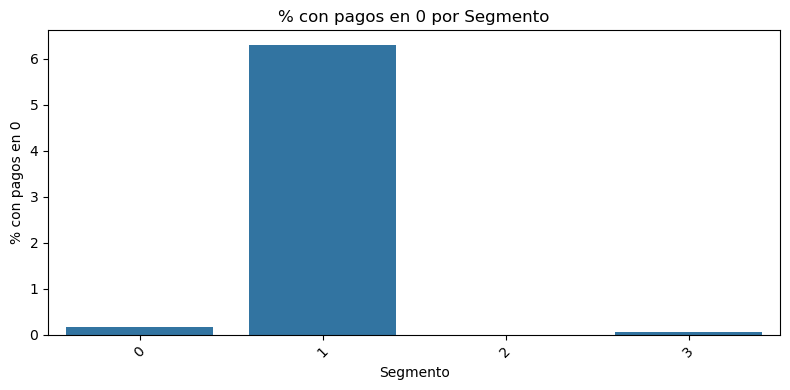

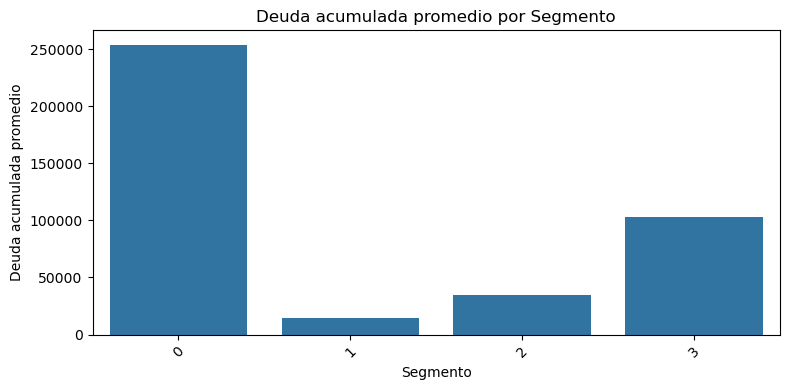

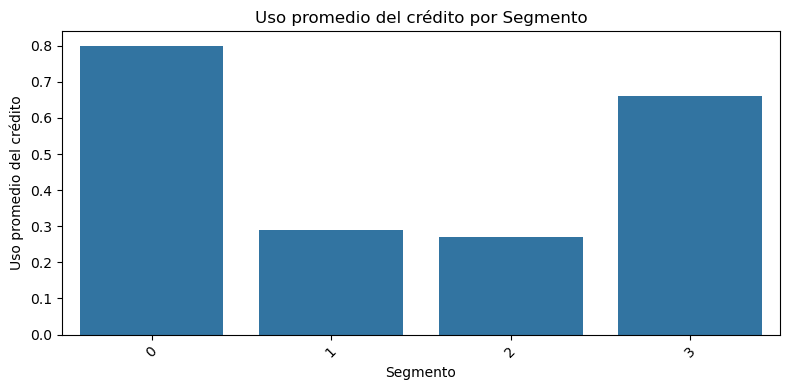

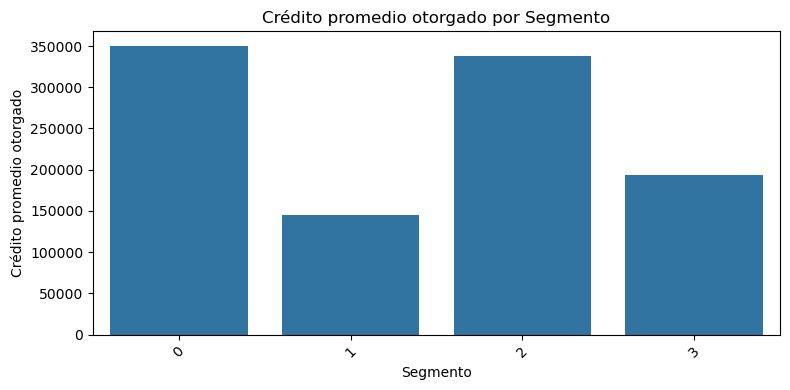

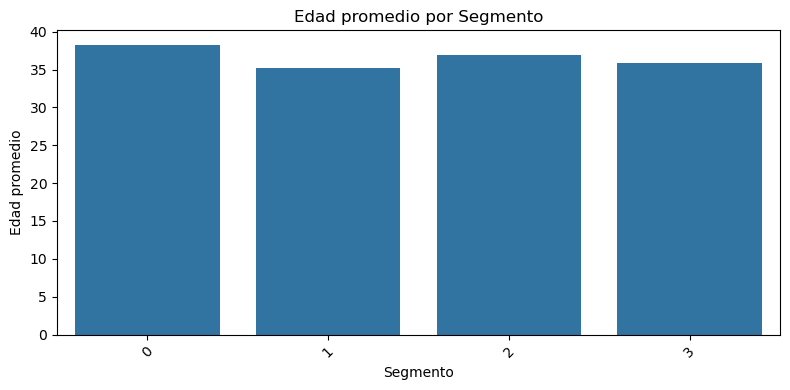

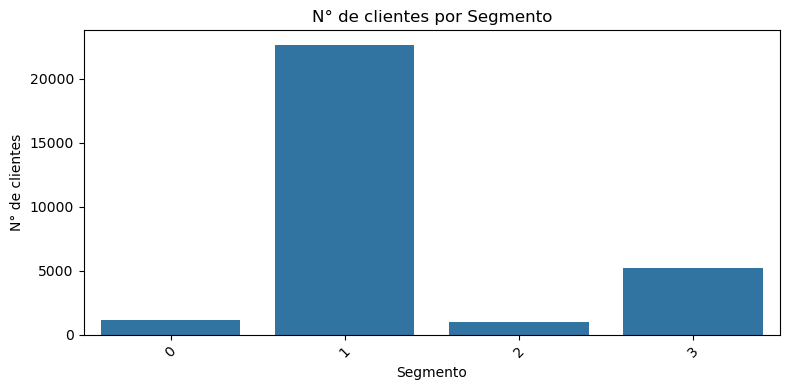

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegura el orden correcto en el índice de la tabla
resumen_segmentos = resumen_segmentos.sort_index()

# 1. Mostrar la tabla de resumen
print("\nResumen de Variables de Alerta por Segmento:\n")
print(resumen_segmentos)

# 2. Gráficos comparativos por variable
variables_a_graficar = [
    "% con pagos en 0",
    "Deuda acumulada promedio",
    "Uso promedio del crédito",
    "Crédito promedio otorgado",
    "Edad promedio",
    "N° de clientes"
]

# Crear un gráfico por variable
for variable in variables_a_graficar:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=resumen_segmentos.index, y=resumen_segmentos[variable])
    plt.title(f"{variable} por Segmento")
    plt.ylabel(variable)
    plt.xlabel("Segmento")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
df["default.payment.next.month"] = pd.to_numeric(df["default.payment.next.month"], errors="coerce")

# 4. Tabla estilo dinámica por segmento, con variable adicional 'default.payment.next.month'
resumen_segmentos = df.groupby("segmento").agg({
    "pagos_en_cero": lambda x: round(x.mean() * 100, 2),                     # % con pagos en 0
    "deuda_acumulada": "mean",                                              # Deuda acumulada promedio
    "uso_credito": "mean",                                                  # Uso promedio del crédito
    "LIMIT_BAL": "mean",                                                    # Crédito promedio otorgado
    "AGE": "mean",                                                          # Edad promedio
    "default.payment.next.month": lambda x: round(x.mean() * 100, 2),       # % con default
    "segmento": "count"                                                     # N° de clientes
}).rename(columns={
    "pagos_en_cero": "% con pagos en 0",
    "deuda_acumulada": "Deuda acumulada promedio",
    "uso_credito": "Uso promedio del crédito",
    "LIMIT_BAL": "Crédito promedio otorgado",
    "AGE": "Edad promedio",
    "default.payment.next.month": "% con default",
    "segmento": "N° de clientes"
}).round(2)

# Ordenar por '% con default' descendente
resumen_segmentos = resumen_segmentos.sort_values(by="% con default", ascending=False)

# 5. Mostrar tabla final
print("\n📊 Resumen tipo tabla dinámica por segmento:\n")
print(resumen_segmentos.to_string())


📊 Resumen tipo tabla dinámica por segmento:

          % con pagos en 0  Deuda acumulada promedio  Uso promedio del crédito  Crédito promedio otorgado  Edad promedio  % con default  N° de clientes
segmento                                                                                                                                               
1                     6.30                  14456.62                      0.29                  144498.19          35.20          23.09           22654
0                     0.17                 253880.82                      0.80                  350359.14          38.26          22.53            1163
3                     0.06                 103076.02                      0.66                  193797.57          35.81          20.65            5177
2                     0.00                  34456.34                      0.27                  338280.32          36.95           7.46            1006


## Sistema de alertas

In [ ]:
# 1. Alerta de riesgo por no pago (morosidad total)
df["alerta_pagos_en_cero"] = (df[[f"PAY_AMT{i}" for i in range(1, 7)]].sum(axis=1) == 0).astype(int)


#Alerta por acumulación sin abono (sospecha de lavado o sobreendeudamiento)
df["alerta_acumulacion_sin_abono"] = df["BILL_AMT6"] > 3 * df["PAY_AMT6"]

#3. Alerta por uso elevado del crédito
df["uso_credito"] = df[[f"BILL_AMT{i}" for i in range(1, 7)]].mean(axis=1) / df["LIMIT_BAL"]
df["alerta_uso_credito_alto"] = df["uso_credito"] > 0.9


#Alerta por pagos mínimos con límite alto
limite_promedio = df["LIMIT_BAL"].mean()
df["alerta_limite_alto_pago_minimo"] = (df["LIMIT_BAL"] > limite_promedio) & \
                                        (df["PAY_AMT6"] < 0.05 * df["LIMIT_BAL"])


#7. Alerta por facturación alta reciente sin pago
df["alerta_factura_sin_pago"] = (df["BILL_AMT6"] > df["BILL_AMT5"] * 1.5) & (df["PAY_AMT6"] == 0)


# Distancia euclidiana desde el origen
df["distancia_pca"] = np.sqrt(df["PCA1"]**2 + df["PCA2"]**2)

# Umbral como percentil 95 (top 5% más alejados)
umbral = df["distancia_pca"].quantile(0.95)

# Alerta por outlier PCA
df["alerta_outlier_pca"] = df["distancia_pca"] > umbral

In [ ]:
df.head(20)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,segmento,PCA1,PCA2,alerta_pagos_en_cero,alerta_acumulacion_sin_abono,alerta_uso_credito_alto,alerta_limite_alto_pago_minimo,alerta_factura_sin_pago,distancia_pca,alerta_outlier_pca
0,20000,2,2,1,24,2,2,-1,-1,-2,...,1,-1.958481,-0.537045,0,False,False,False,False,2.030779,False
1,120000,2,2,2,26,-1,2,0,0,0,...,1,-1.735307,-0.217341,0,False,False,False,False,1.748865,False
2,90000,2,2,2,34,0,0,0,0,0,...,1,-1.224240,-0.284887,0,True,False,False,False,1.256950,False
3,50000,2,2,1,37,0,0,0,0,0,...,1,-0.540935,-0.666624,0,True,False,False,False,0.858486,False
4,50000,1,2,1,57,-1,0,-1,0,0,...,1,-0.848741,0.739026,0,True,False,False,False,1.125399,False
5,50000,1,1,2,37,0,0,0,0,0,...,1,-0.536934,-0.711996,0,True,False,False,False,0.891760,False
6,500000,1,1,2,29,0,0,0,0,0,...,0,15.880763,-0.961255,0,True,True,True,False,15.909828,True
7,100000,2,2,2,23,0,-1,-1,0,0,...,1,-1.802214,-0.292339,0,False,False,False,False,1.825770,False
8,140000,2,3,1,28,0,0,2,0,0,...,1,-1.409711,-0.208825,0,True,False,False,False,1.425094,False
9,20000,1,3,2,35,-2,-2,-2,-2,-1,...,1,-1.685796,-0.176236,0,True,False,False,False,1.694983,False


In [ ]:
from google.colab import files

# Guardar como archivo Excel
df.to_excel("Segementación.xlsx", index=False)

# Descargar
files.download("Segementación.xlsx")